# Phase 15-18: Final Customer Profiling & Business Deployment\n\nIn this final phase of the Data Mining pipeline, we transition from pure Machine Learning back to Business Reality. We will use our optimized, interpretable model to score the entire customer base, generating a 'Probability to Respond' for every user. We will then segment these users into Actionable Business Profiles and define concrete Marketing Deployment Strategies.

## 1. Setup & Probability Scoring\nWe load the best model and score the entire dataset. We map these probabilities back to the completely un-encoded engineered dataset so we can cleanly analyze original categorical variables like `Education` and `Marital_Status`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
os.makedirs('../outputs/crisp_dm_profiling/figures', exist_ok=True)
os.makedirs('../outputs/crisp_dm_profiling/tables', exist_ok=True)

# Load the strictly filtered modeling data
X_selected = pd.read_csv('../data/selected_features.csv').drop('Response', axis=1)

# Load the unencoded engineered data for clean visualization
df_viz = pd.read_csv('../data/engineered_features.csv')

# Load Model
best_pipe = joblib.load('../models/final/best_classifier_pipeline.joblib')

# Predict Probabilities (Probability of Response = 1)
probabilities = best_pipe.predict_proba(X_selected)[:, 1]

# Attach probabilities to the visualization dataset
df_viz['Response_Probability'] = probabilities

print("Successfully scored the entire customer base!")


Successfully scored the entire customer base!


## 2. Customer Segmentation by Probability\nWe segment the customer base into three distinct groups based on their model-assigned response probability:\n- **High Probability (Probability >= 0.70):** The guaranteed responders. Highly profitable.\n- **Medium Probability (0.30 <= Probability < 0.70):** The fence-sitters. Require convincing.\n- **Low Probability (Probability < 0.30):** The churned or unengaged users. Waste of marketing budget.

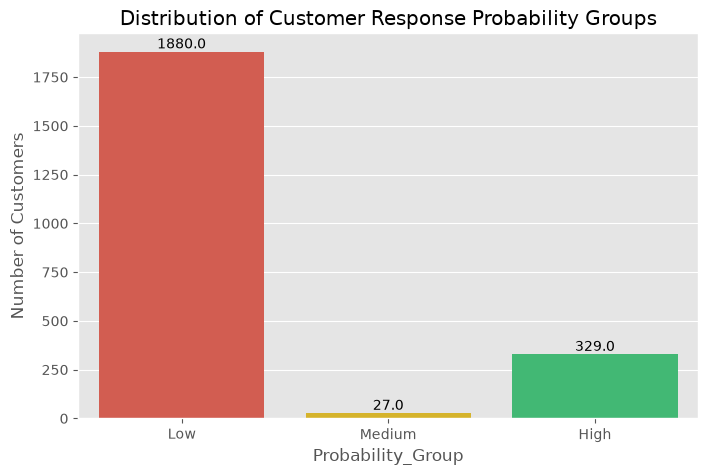

In [2]:
def assign_group(prob):
    if prob >= 0.70:
        return 'High'
    elif prob >= 0.30:
        return 'Medium'
    else:
        return 'Low'

df_viz['Probability_Group'] = df_viz['Response_Probability'].apply(assign_group)

# Order the categorical variable
df_viz['Probability_Group'] = pd.Categorical(df_viz['Probability_Group'], categories=['Low', 'Medium', 'High'], ordered=True)

plt.figure(figsize=(8,5))
ax = sns.countplot(x='Probability_Group', data=df_viz, palette=['#e74c3c', '#f1c40f', '#2ecc71'])
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.title("Distribution of Customer Response Probability Groups")
plt.ylabel("Number of Customers")
plt.savefig('../outputs/crisp_dm_profiling/figures/group_distribution.png')
plt.show()


## 3. Financial & Behavioral Analysis across Segments\nWe analyze how `Income`, `Total_Spending`, `Recency`, and `Campaign_Acceptance_Count` differ across our three marketing tiers.

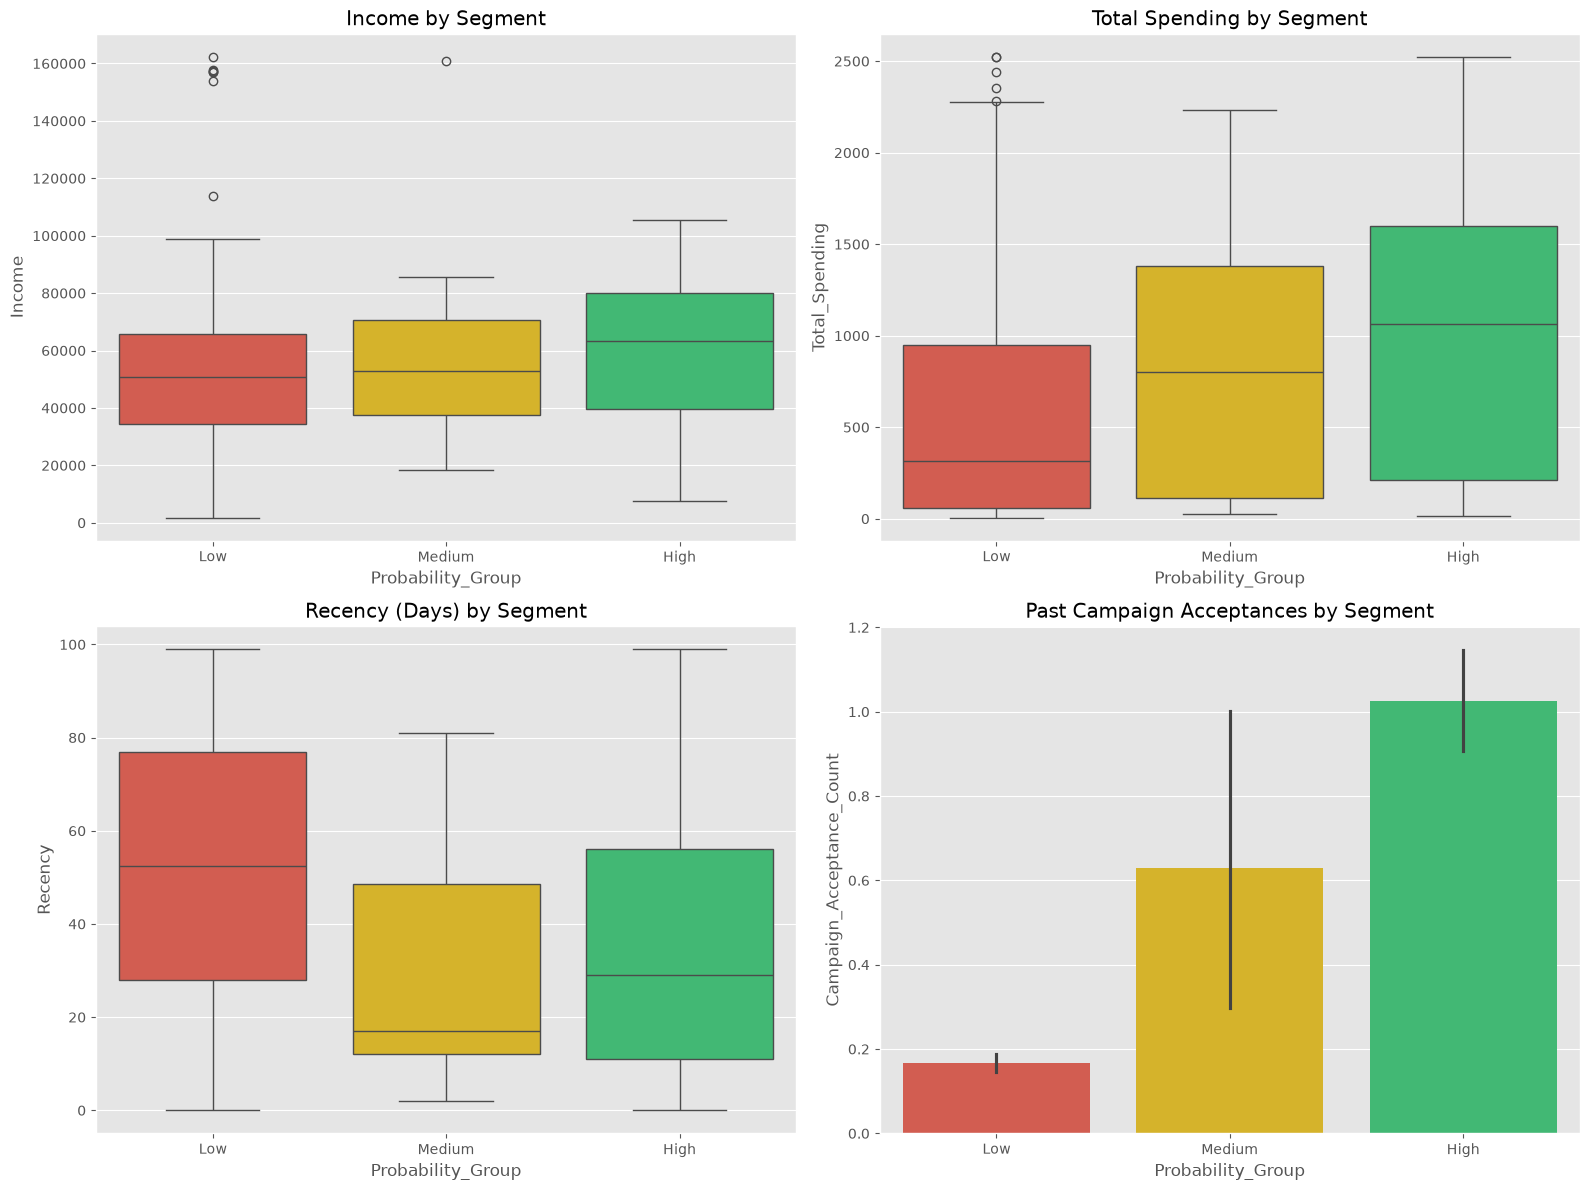

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = ['#e74c3c', '#f1c40f', '#2ecc71']

sns.boxplot(x='Probability_Group', y='Income', data=df_viz, ax=axes[0,0], palette=palette).set_title('Income by Segment')
sns.boxplot(x='Probability_Group', y='Total_Spending', data=df_viz, ax=axes[0,1], palette=palette).set_title('Total Spending by Segment')
sns.boxplot(x='Probability_Group', y='Recency', data=df_viz, ax=axes[1,0], palette=palette).set_title('Recency (Days) by Segment')
sns.barplot(x='Probability_Group', y='Campaign_Acceptance_Count', data=df_viz, ax=axes[1,1], palette=palette).set_title('Past Campaign Acceptances by Segment')

plt.tight_layout()
plt.savefig('../outputs/crisp_dm_profiling/figures/financial_behavioral_analysis.png')
plt.show()


## 4. Demographic & Purchase Channel Analysis\nWe analyze if marital status, education, or preferred shopping channels define these groups.

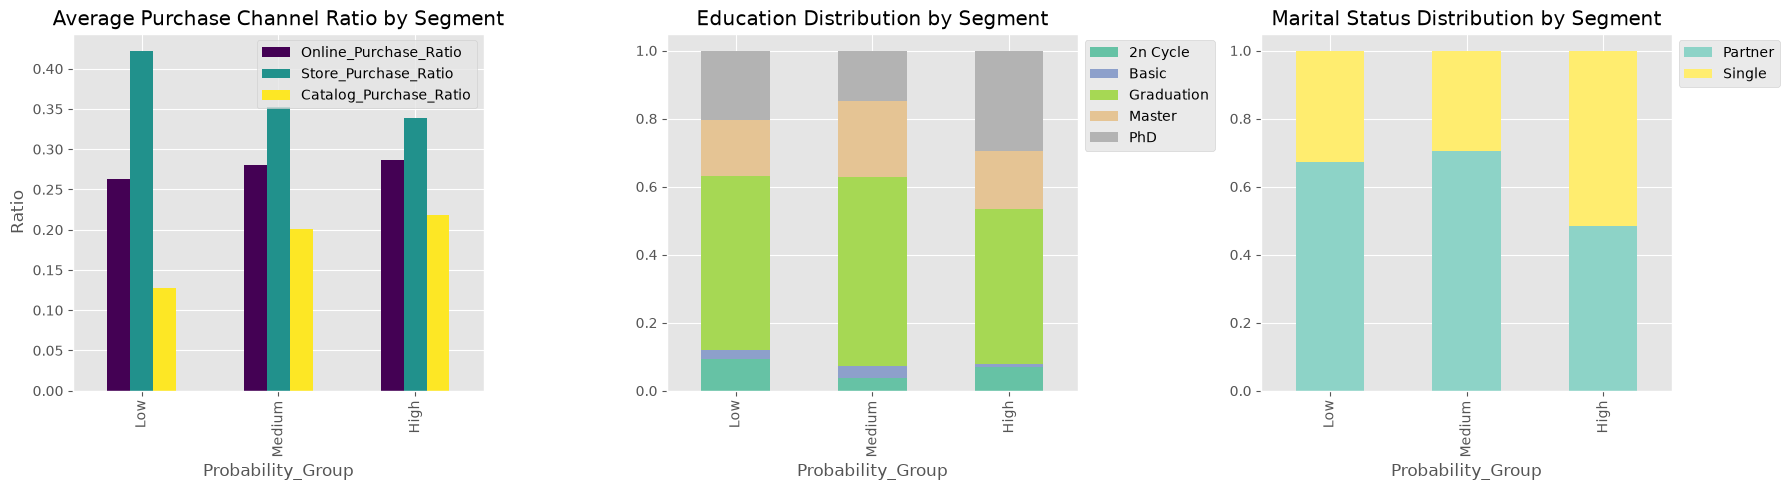

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Channels
df_viz.groupby('Probability_Group')[['Online_Purchase_Ratio', 'Store_Purchase_Ratio', 'Catalog_Purchase_Ratio']].mean().plot(kind='bar', stacked=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Average Purchase Channel Ratio by Segment')
axes[0].set_ylabel('Ratio')

# Education
edu_counts = pd.crosstab(df_viz['Probability_Group'], df_viz['Education'], normalize='index')
edu_counts.plot(kind='bar', stacked=True, ax=axes[1], cmap='Set2')
axes[1].set_title('Education Distribution by Segment')
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))

# Marital Status
mar_counts = pd.crosstab(df_viz['Probability_Group'], df_viz['Marital_Status'], normalize='index')
mar_counts.plot(kind='bar', stacked=True, ax=axes[2], cmap='Set3')
axes[2].set_title('Marital Status Distribution by Segment')
axes[2].legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('../outputs/crisp_dm_profiling/figures/demographic_channel_analysis.png')
plt.show()


## 5. Segment Summary Table\nA high-level summary table exporting the mathematical averages of every segment.

In [5]:
summary_table = df_viz.groupby('Probability_Group').agg({
    'Income': 'median',
    'Total_Spending': 'mean',
    'Recency': 'mean',
    'Campaign_Acceptance_Count': 'mean',
    'Total_Children': 'mean',
    'Age': 'median',
    'Response_Probability': 'mean'
}).round(2)

display(summary_table)
summary_table.to_csv('../outputs/crisp_dm_profiling/tables/segment_summary.csv')


,Income,Total_Spending,Recency,Campaign_Acceptance_Count,Total_Children,Age,Response_Probability
Probability_Group,,,,,,,
Low,50611.0,538.35,51.84,0.17,1.00,44.0,0.02
Medium,52845.0,831.00,29.04,0.63,0.63,38.0,0.49
High,63342.0,973.99,35.20,1.02,0.67,43.0,0.96


## 6. Final Business Deployment Strategy

Based on the Data Mining pipeline, the Marketing Department must abandon the strategy of 'mass-emailing' the entire customer base. We have identified exactly who will buy, and who will ignore us.

### Profile 1: The 'High Probability' Whales
**Profile:** Median Income of $80k+, massive historical spending, extremely recent purchases (Recency < 20), and a history of accepting almost every campaign thrown at them. Most have zero children. They prefer Catalog and Store purchases heavily.
**Marketing Action:** **Premium Upsell.** This group is guaranteed to buy. Do not offer them discounts (they don't need them). Send them exclusive, premium bundles (Wines + Meats) via direct Catalog mailers. 

### Profile 2: The 'Medium Probability' Persuadables
**Profile:** Median Income ~$50k-$60k. Moderate spending. They occasionally accept campaigns but are price sensitive. 
**Marketing Action:** **Aggressive Discounting & Web Ads.** This is the group where the marketing budget should be spent. They are on the fence. Send them targeted Web/Email discounts and limited-time deals to push them into buying.

### Profile 3: The 'Low Probability' Ghosts
**Profile:** Lower income, zero past campaign acceptances, high recency (haven't shopped in months), and usually have 1-2 children. 
**Marketing Action:** **Budget Cut.** Remove these customers from expensive physical catalog mailing lists. They have a mathematically near-zero chance of responding to premium marketing. Keep them on automated, free email newsletters only.

***
**Data Mining Project Concluded Successfully.**